<a href="https://colab.research.google.com/github/Fahadkhan2450/Emotion-Detection-From-Social-Media-Posts/blob/main/RNN%2CLSTM%2CBISLSTM_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
     SpatialDropout1D,
    GlobalMaxPooling1D,
    LSTM,
    SimpleRNN,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re
from nltk.corpus import stopwords

import bz2
import csv
import re

In [2]:
import kagglehub

path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


In [3]:
file_path = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)
print(df.columns)

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
(53043, 3)
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


**Keep only required columns**

In [4]:
df = df[["statement", "status"]]
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


**Remove duplicate records**

In [5]:
df = df.drop_duplicates()
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety
52836,anxiety heart symptom does anyone else have th...,Anxiety
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
52839,fomo from things i’m not involved in does anyo...,Anxiety


**Remove missing values**

In [6]:
df = df.dropna(subset=["statement", "status"])
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety
52836,anxiety heart symptom does anyone else have th...,Anxiety
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
52839,fomo from things i’m not involved in does anyo...,Anxiety


**Remove duplicate records**

In [7]:
df = df.drop_duplicates()
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety
52836,anxiety heart symptom does anyone else have th...,Anxiety
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
52839,fomo from things i’m not involved in does anyo...,Anxiety


**Convert text to string**

In [8]:
df["statement"] = df["statement"].astype(str)
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety
52836,anxiety heart symptom does anyone else have th...,Anxiety
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
52839,fomo from things i’m not involved in does anyo...,Anxiety


In [9]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["status"].value_counts())

Dataset shape: (51093, 2)

Class distribution:
status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64


**Encoding Labels**

In [10]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["status"])

class_names = label_encoder.classes_

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : Anxiety
1 : Bipolar
2 : Depression
3 : Normal
4 : Personality disorder
5 : Stress
6 : Suicidal


**Train/Test Split**

In [11]:
train_text, test_text, train_labels, test_labels = train_test_split(
    df["statement"].values,
    df["label"].values,
    test_size=0.20,
    random_state=42,
    stratify=df["label"].values
)

**Second split: take 10% of training data for validation**

In [12]:
train_text, val_text, train_labels, val_labels = train_test_split(
    train_text,
    train_labels,
    test_size=0.10,
    random_state=42,
    stratify=train_labels
)


In [13]:
print("Training samples:", len(train_text))
print("Validation samples:", len(val_text))
print("Testing samples:", len(test_text))

Training samples: 36786
Validation samples: 4088
Testing samples: 10219


In [14]:
df

,statement,status,label
0,oh my gosh,Anxiety,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0
3,I've shifted my focus to something else but I'...,Anxiety,0
4,"I'm restless and restless, it's been a month n...",Anxiety,0
...,...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety,0
52836,anxiety heart symptom does anyone else have th...,Anxiety,0
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety,0
52839,fomo from things i’m not involved in does anyo...,Anxiety,0


**For RNN AND LSTM using Keras Tokenzer**

In [15]:
MAX_WORDS = 30000
MAX_LEN = 200

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_text)

**Converting text into sequence**

In [16]:
X_train = tokenizer.texts_to_sequences(train_text)
X_val = tokenizer.texts_to_sequences(val_text)
X_test = tokenizer.texts_to_sequences(test_text)

**Padding For making text of same length**

In [17]:
X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)



In [18]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (36786, 200)
X_val: (4088, 200)
X_test: (10219, 200)


**Simple RNN Model**

In [24]:
num_classes = len(class_names)

rnn_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    SpatialDropout1D(0.25),

    SimpleRNN(
        128,
        return_sequences=True
    ),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        num_classes,
        activation="softmax"
    )
])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,881,607 (14.81 MB)

 Trainable params: 3,881,607 (14.81 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
rnn_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Train RNN**

In [26]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

rnn_checkpoint = ModelCheckpoint(
    "best_rnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [27]:
rnn_history = rnn_model.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr,
        rnn_checkpoint
    ],
    verbose=1
)

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4730 - loss: 1.4724 - val_accuracy: 0.5541 - val_loss: 1.2313 - learning_rate: 3.0000e-04
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5504 - loss: 1.2207 - val_accuracy: 0.5837 - val_loss: 1.0759 - learning_rate: 3.0000e-04
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5733 - loss: 1.0697 - val_accuracy: 0.5954 - val_loss: 0.9444 - learning_rate: 3.0000e-04
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6068 - loss: 0.9098 - val_accuracy: 0.6216 - val_loss: 0.8407 - learning_rate: 3.0000e-04
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.6295 - loss: 0.8351 - val_accuracy: 0.6485 - val_loss: 0.8141 - learning_rate: 3.0000e-04
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.6527 - loss: 0.7625 - val_accuracy: 0.6727 - val_loss: 0.8021 - learning_rate: 3.0000e-04
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/ste

In [28]:
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test,
    test_labels,
    verbose=1
)

print("RNN Test Loss:", rnn_test_loss)
print("RNN Test Accuracy:", rnn_test_accuracy)

320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7001 - loss: 0.7494
RNN Test Loss: 0.7494325637817383
RNN Test Accuracy: 0.700068473815918


**RNN predictions**

In [29]:
rnn_probabilities = rnn_model.predict(X_test)

rnn_predictions = np.argmax(
    rnn_probabilities,
    axis=1
)

320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


**Classsification Report for RNN**

In [30]:
print(
    classification_report(
        test_labels,
        rnn_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

             Anxiety     0.5404    0.7931    0.6428       725
             Bipolar     0.6294    0.6760    0.6519       500
          Depression     0.6701    0.5585    0.6092      3019
              Normal     0.9184    0.9333    0.9258      3208
Personality disorder     0.0000    0.0000    0.0000       179
              Stress     0.3718    0.1264    0.1886       459
            Suicidal     0.5596    0.7060    0.6243      2129

            accuracy                         0.7001     10219
           macro avg     0.5271    0.5419    0.5204     10219
        weighted avg     0.6887    0.7001    0.6866     10219



**COnfusion Matrix for RNN**

<Figure size 1000x800 with 0 Axes>

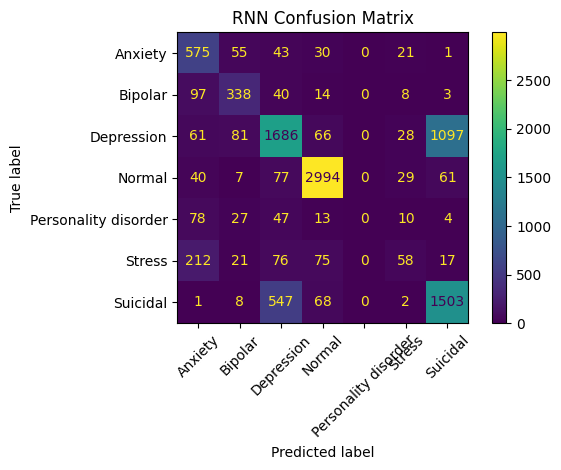

In [31]:
cm = confusion_matrix(
    test_labels,
    rnn_predictions
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("RNN Confusion Matrix")
plt.tight_layout()
plt.show()

**RNN Training Curves**

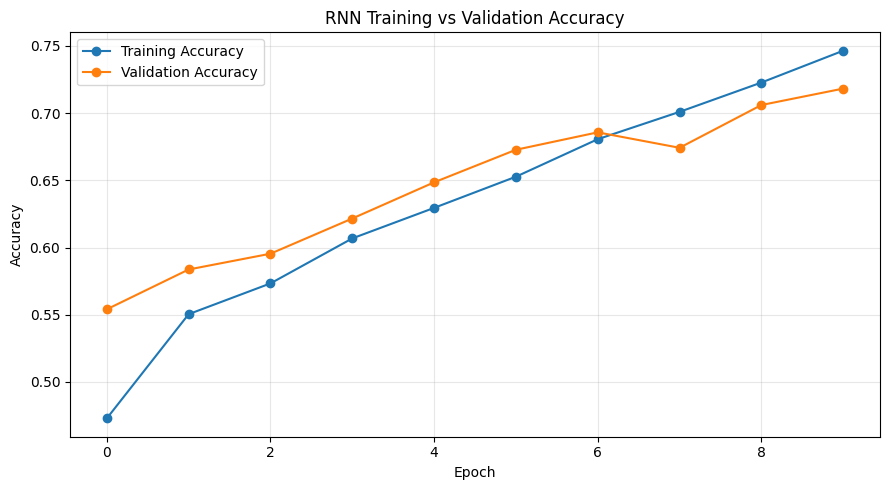

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    rnn_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**LOSS CHECK**

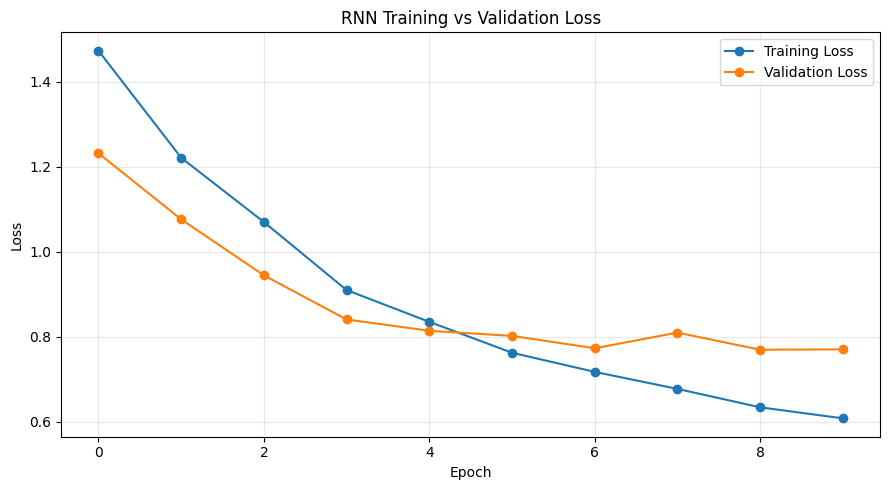

In [33]:
plt.figure(figsize=(9, 5))

plt.plot(
    rnn_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**LSTM**

In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

num_classes = len(class_names)

lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    SpatialDropout1D(0.25),

    LSTM(
        128,
        return_sequences=True
    ),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        num_classes,
        activation="softmax"
    )
])

lstm_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_18            │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 200, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_17         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,980,295 (15.18 MB)

 Trainable params: 3,980,295 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

**Compile LSTM**

In [139]:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [140]:
lstm_history = lstm_model.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5208 - loss: 1.2825 - val_accuracy: 0.6079 - val_loss: 0.9409 - learning_rate: 5.0000e-04
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6124 - loss: 0.9069 - val_accuracy: 0.6583 - val_loss: 0.7940 - learning_rate: 5.0000e-04
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6644 - loss: 0.7726 - val_accuracy: 0.6813 - val_loss: 0.7586 - learning_rate: 5.0000e-04
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6961 - loss: 0.7096 - val_accuracy: 0.6977 - val_loss: 0.7525 - learning_rate: 5.0000e-04
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7288 - loss: 0.6475 - val_accuracy: 0.7199 - val_loss: 0.7137 - learning_rate: 5.0000e-04
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7695 - loss: 0.5800 - val_accuracy: 0.7258 - val_loss: 0.6840 - learning_rate: 5.0000e-04
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step

**Evaluate LSTM**

In [141]:
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test,
    test_labels,
    verbose=1
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7462 - loss: 0.6616
LSTM Test Loss: 0.6615839600563049
LSTM Test Accuracy: 0.7461591362953186


**LSTM Predictions**

In [142]:
lstm_probabilities = lstm_model.predict(X_test)

lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


**LSTM Classification Report**

In [143]:
print(
    classification_report(
        test_labels,
        lstm_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

             Anxiety     0.7991    0.7407    0.7688       725
             Bipolar     0.6413    0.7260    0.6811       500
          Depression     0.7265    0.6645    0.6941      3019
              Normal     0.9217    0.9177    0.9197      3208
Personality disorder     0.1579    0.0168    0.0303       179
              Stress     0.3951    0.5294    0.4525       459
            Suicidal     0.6392    0.7182    0.6764      2129

            accuracy                         0.7462     10219
           macro avg     0.6116    0.6162    0.6033     10219
        weighted avg     0.7458    0.7462    0.7434     10219



**LSTM Confusion Mtarix**

<Figure size 1000x800 with 0 Axes>

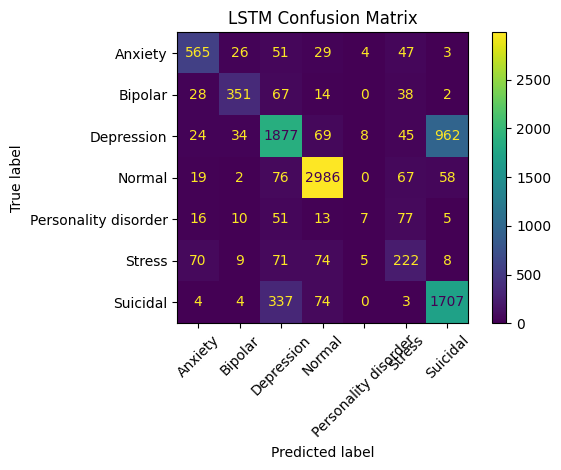

In [40]:
cm_lstm = confusion_matrix(
    test_labels,
    lstm_predictions
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

**LSTM Accuracy Graph**

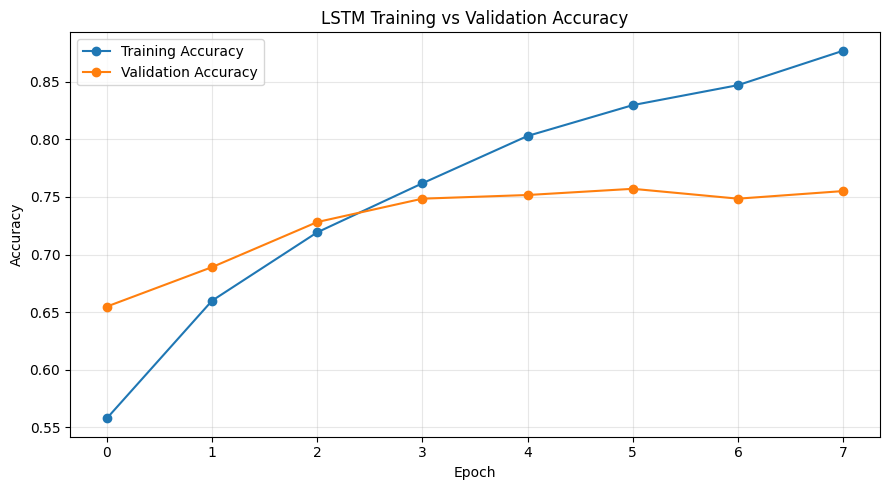

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    lstm_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

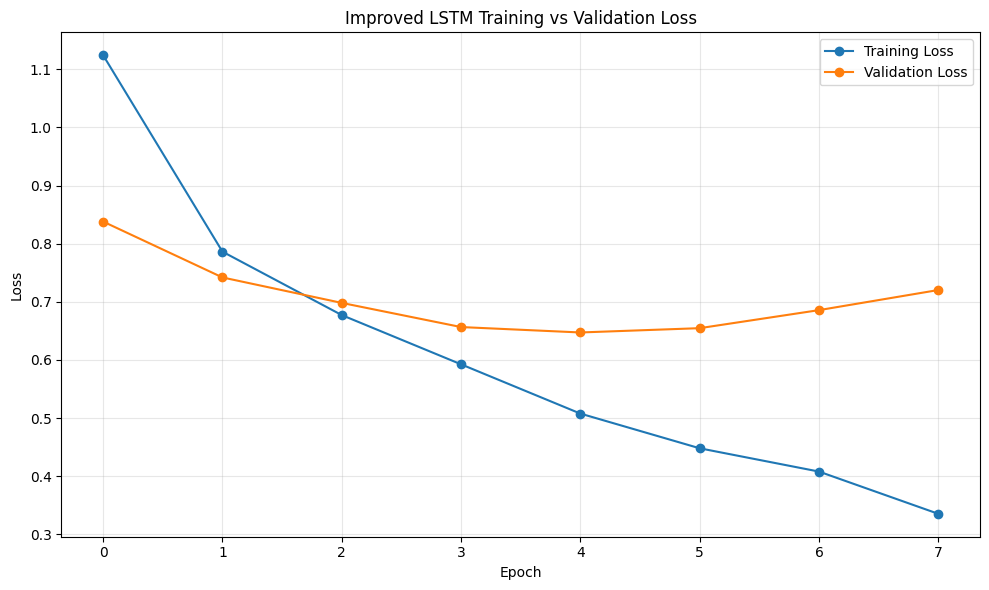

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    lstm_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Improved LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**RNN Evaluation**

In [43]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    test_labels,
    verbose=0
)

rnn_prob = rnn_model.predict(X_test, verbose=0)
rnn_pred = np.argmax(rnn_prob, axis=1)

rnn_precision = precision_score(
    test_labels,
    rnn_pred,
    average="weighted",
    zero_division=0
)

rnn_recall = recall_score(
    test_labels,
    rnn_pred,
    average="weighted",
    zero_division=0
)

rnn_f1 = f1_score(
    test_labels,
    rnn_pred,
    average="weighted",
    zero_division=0
)





**LSTM Evaluation**

In [44]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    test_labels,
    verbose=0
)

lstm_prob = lstm_model.predict(X_test, verbose=0)
lstm_pred = np.argmax(lstm_prob, axis=1)

lstm_precision = precision_score(
    test_labels,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    test_labels,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    test_labels,
    lstm_pred,
    average="weighted",
    zero_division=0
)


**Combined Results Table**

In [45]:
results = pd.DataFrame({
    "Model": [" RNN ", " LSTM "],
    "Loss": [rnn_loss, lstm_loss],
    "Accuracy": [rnn_accuracy, lstm_accuracy],
    "Precision": [rnn_precision, lstm_precision],
    "Recall": [rnn_recall, lstm_recall],
    "F1-Score": [rnn_f1, lstm_f1]
})


**Convert scores to percentages**

In [46]:
 results[["Accuracy", "Precision", "Recall", "F1-Score"]] *= 100

results = results.round(2)

print(results)

    Model  Loss  Accuracy  Precision  Recall  F1-Score
0    RNN   0.75     70.01      68.87   70.01     68.66
1   LSTM   0.63     75.50      75.61   75.50     74.97


**BILSTM**

In [122]:
import os
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Remove previous checkpoint
if os.path.exists("best_bilstm.keras"):
    os.remove("best_bilstm.keras")

num_classes = len(class_names)

# ==========================================
# Tuned BiLSTM
# ==========================================

bilstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    SpatialDropout1D(0.15),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.10,
            kernel_regularizer=l2(1e-5)
        )
    ),

    GlobalMaxPooling1D(),

    Dropout(0.25),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-5)
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])



bilstm_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_17            │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 200, 128)       │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_16         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,527 (15.06 MB)

 Trainable params: 3,947,527 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

**Compiling Model**

In [123]:
bilstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [125]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_delta=0.0005,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_bilstm.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

**Evaluating model**

In [126]:
import os

if os.path.exists("best_bilstm.keras"):
    os.remove("best_bilstm.keras")

In [127]:
bilstm_history = bilstm_model.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=15,
    batch_size=64,
    callbacks=[
        bilstm_early_stopping,
        bilstm_reduce_lr,
        bilstm_checkpoint
    ],
    verbose=1
)

Epoch 1/15
574/575 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5500 - loss: 1.2012
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 1: val_loss did not improve from 0.71349
575/575 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6178 - loss: 0.9662 - val_accuracy: 0.7118 - val_loss: 0.7375 - learning_rate: 0.0010
Epoch 2/15
574/575 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7473 - loss: 0.6365
Epoch 2: val_loss improved from 0.71349 to 0.61516, saving model to best_bilstm.keras

Epoch 2: finished saving model to best_bilstm.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.7610 - loss: 0.6149 - val_accuracy: 0.7591 - val_loss: 0.6152 - learning_rate: 5.0000e-04
Epoch 3/15
574/575 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8046 - loss: 0.5098
Epoch 3: val_loss improved from 0.61516 to 0.60529, saving model to best_bilstm.keras

Epoch 3: finished saving model to best_bilstm.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - ac

In [128]:
bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test,
    test_labels,
    verbose=1
)

print("BiLSTM Test Loss:", bilstm_test_loss)
print("BiLSTM Test Accuracy:", bilstm_test_accuracy)

320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7748 - loss: 0.5756
BiLSTM Test Loss: 0.5755937099456787
BiLSTM Test Accuracy: 0.7748311758041382


In [129]:
comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "BiLSTM"
    ],

    "Training Accuracy": [
        rnn_history.history["accuracy"][-1],
        lstm_history.history["accuracy"][-1],
        bilstm_history.history["accuracy"][-1]
    ],

    "Validation Accuracy": [
        rnn_history.history["val_accuracy"][-1],
        lstm_history.history["val_accuracy"][-1],
        bilstm_history.history["val_accuracy"][-1]
    ],

    "Training Loss": [
        rnn_history.history["loss"][-1],
        lstm_history.history["loss"][-1],
        bilstm_history.history["loss"][-1]
    ],

    "Validation Loss": [
        rnn_history.history["val_loss"][-1],
        lstm_history.history["val_loss"][-1],
        bilstm_history.history["val_loss"][-1]
    ],

    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        bilstm_model.count_params()
    ]
})

comparison["Training Accuracy"] = (
    comparison["Training Accuracy"] * 100
).round(2)

comparison["Validation Accuracy"] = (
    comparison["Validation Accuracy"] * 100
).round(2)

comparison["Training Loss"] = comparison["Training Loss"].round(4)
comparison["Validation Loss"] = comparison["Validation Loss"].round(4)

comparison

,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss,Parameters
0,Simple RNN,74.64,71.82,0.6083,0.7704,3881607
1,LSTM,87.70,75.51,0.3355,0.7203,4120071
2,BiLSTM,86.66,76.47,0.3677,0.6388,3947527


**Get predicted probabilities**

In [130]:
y_prob = bilstm_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


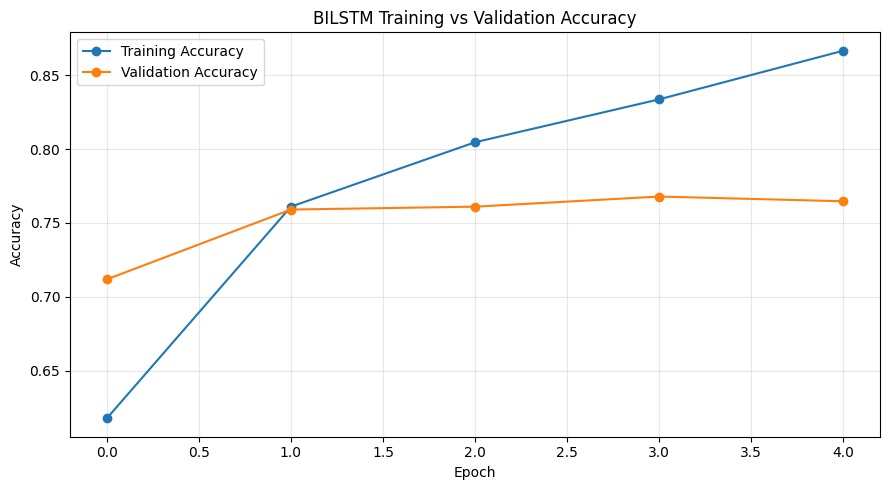

In [131]:
plt.figure(figsize=(9, 5))

plt.plot(
    bilstm_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    bilstm_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BILSTM Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Convert true labels to One-vs-Rest format**

In [132]:
y_test_bin = label_binarize(
    test_labels,
    classes=np.arange(num_classes)
)







**Calculate ROC curve for each class**

In [133]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

**PLot Multi Curve ROC**

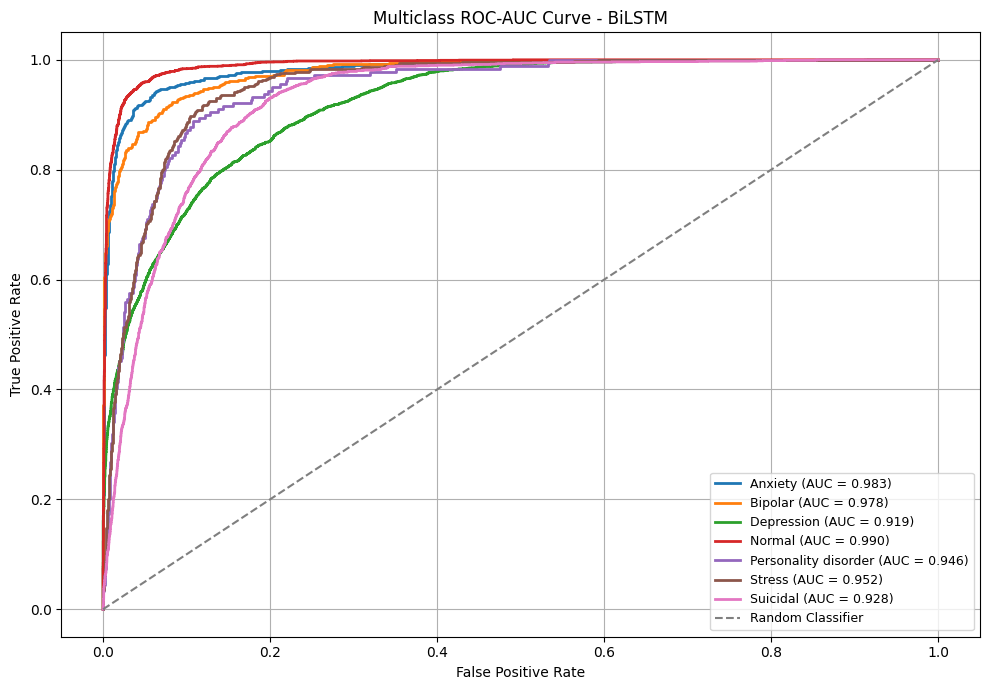

In [134]:
plt.figure(figsize=(10, 7))

for i in range(num_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC-AUC Curve - BiLSTM")

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [144]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================
# Predictions
# ==========================================

rnn_prob = rnn_model.predict(X_val, verbose=0)
lstm_prob = lstm_model.predict(X_val, verbose=0)
bilstm_prob = bilstm_model.predict(X_val, verbose=0)

rnn_pred = np.argmax(rnn_prob, axis=1)
lstm_pred = np.argmax(lstm_prob, axis=1)
bilstm_pred = np.argmax(bilstm_prob, axis=1)

# ==========================================
# Make sure labels are 1D
# ==========================================

val_true = np.asarray(val_labels)

if val_true.ndim > 1:
    val_true = np.argmax(val_true, axis=1)

# ==========================================
# Score function
# ==========================================

def calculate_scores(y_true, y_pred, history):

    return {
        "Accuracy (%)": accuracy_score(
            y_true, y_pred
        ) * 100,

        "Precision (%)": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,

        "Recall (%)": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,

        "F1-Score (%)": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100,

        "Training Loss": history.history["loss"][-1],

        "Validation Loss": history.history["val_loss"][-1]
    }

# ==========================================
# Comparison
# ==========================================

results = {
    "RNN": calculate_scores(
        val_true,
        rnn_pred,
        rnn_history
    ),

    "LSTM": calculate_scores(
        val_true,
        lstm_pred,
        lstm_history
    ),

    "BiLSTM": calculate_scores(
        val_true,
        bilstm_pred,
        bilstm_history
    )
}

score_table = pd.DataFrame(results).T

score_table.index.name = "Model"

score_table = score_table.round({
    "Accuracy (%)": 2,
    "Precision (%)": 2,
    "Recall (%)": 2,
    "F1-Score (%)": 2,
    "Training Loss": 4,
    "Validation Loss": 4
})

display(score_table)

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Training Loss,Validation Loss
Model,,,,,,
RNN,70.60,69.36,70.60,69.48,0.6083,0.7704
LSTM,73.83,74.64,73.83,73.79,0.3765,0.7408
BiLSTM,76.10,76.48,76.10,75.79,0.3677,0.6388
